In [2]:
from pickle import FALSE

import kagglehub

# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dowlu\.cache\kagglehub\datasets\usdot\flight-delays\versions\1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# On charge les vols et les noms des compagnies
print("Chargement des données... (cela peut prendre quelques secondes)")
df_flights = pd.read_csv(f"{path}/flights.csv", low_memory=False)
df_airlines = pd.read_csv(f"{path}/airlines.csv")

# Cela remplace 'AA' par 'American Airlines Inc.' -> plus joli pour les graphes
df = df_flights.merge(df_airlines, left_on='AIRLINE', right_on='IATA_CODE')

# Echantillonage - On garde 100 000 lignes au hasard pour travailler vite
# Si tu as un PC de guerre, tu peux mettre 500000, mais 100k suffit pour l'école
df_sample = df.sample(n=100000, random_state=42).copy()

print(f"Taille originale : {df.shape}")
print(f"Taille de l'échantillon de travail : {df_sample.shape}")
df_sample.head()

Chargement des données... (cela peut prendre quelques secondes)
Taille originale : (5819079, 33)
Taille de l'échantillon de travail : (100000, 33)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE_y
1508570,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,EV,Atlantic Southeast Airlines
363270,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.
3003945,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,WN,Southwest Airlines Co.
2291425,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,0,0,NaN,0.0,0.0,0.0,152.0,0.0,WN,Southwest Airlines Co.
2973084,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,UA,United Air Lines Inc.


In [6]:
# On garde uniquement les colonnes utiles pour la prédiction AVANT le vol
# On enlève les infos qu'on ne connait qu'après l'atterrissage (Arrival delay, diverted, etc.)
cols_to_keep = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE_x', 'AIRLINE_y', # AIRLINE est le nom complet
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
    'DISTANCE', 'DEPARTURE_DELAY'
]
df_clean = df_sample[cols_to_keep].copy()
df_clean.head()

# Si DEPARTURE_DELAY est vide, c'est souvent un vol annulé. On les supprime pour ce projet.
df_clean = df_clean.dropna(subset=['DEPARTURE_DELAY'])

# 1 = Retard > 15 min, 0 = À l'heure
df_clean['delayed'] = (df_clean['DEPARTURE_DELAY'] > 15).astype(int)

print("Delay Repartition")
print(df_clean['delayed'].value_counts(normalize=True))

Delay Repartition
delayed
0    0.821821
1    0.178179
Name: proportion, dtype: float64


C:\Users\dowlu\AppData\Local\Temp\ipykernel_8944\2876121363.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_stats.values, y=airline_stats.index, palette='viridis')


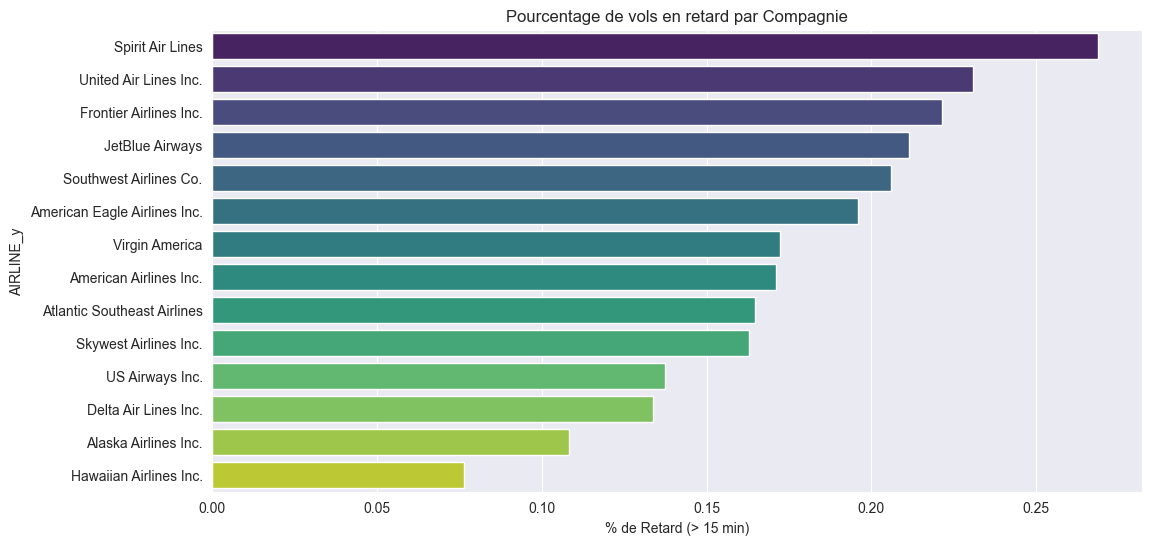

In [12]:
plt.figure(figsize=(12, 6))
# On calcule le % de retard par compagnie
airline_stats = df_clean.groupby('AIRLINE_y')['delayed'].mean().sort_values(ascending=False)

sns.barplot(x=airline_stats.values, y=airline_stats.index, palette='viridis')
plt.title('Pourcentage de vols en retard par Compagnie')
plt.xlabel('% de Retard (> 15 min)')
plt.show()

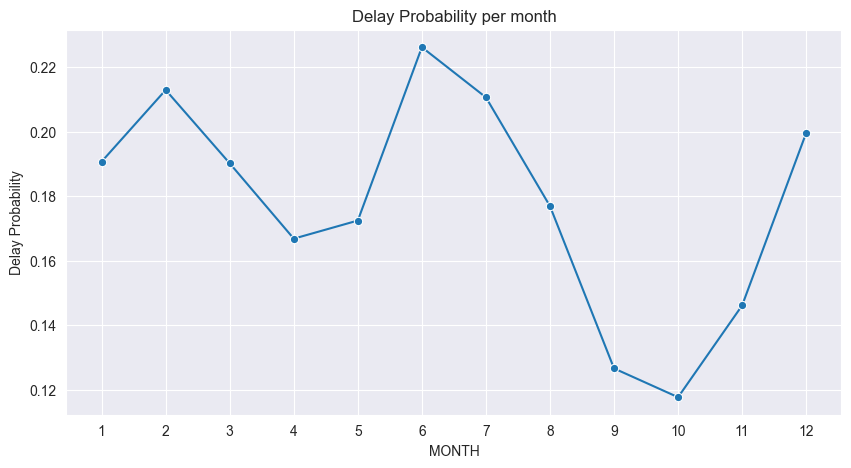

In [14]:
plt.figure(figsize=(10, 5))
# 1 = January, 12 = December
sns.lineplot(data=df_clean, x='MONTH', y='delayed', errorbar=None, marker='o')
plt.title('Delay Probability per month')
plt.ylabel('Delay Probability')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

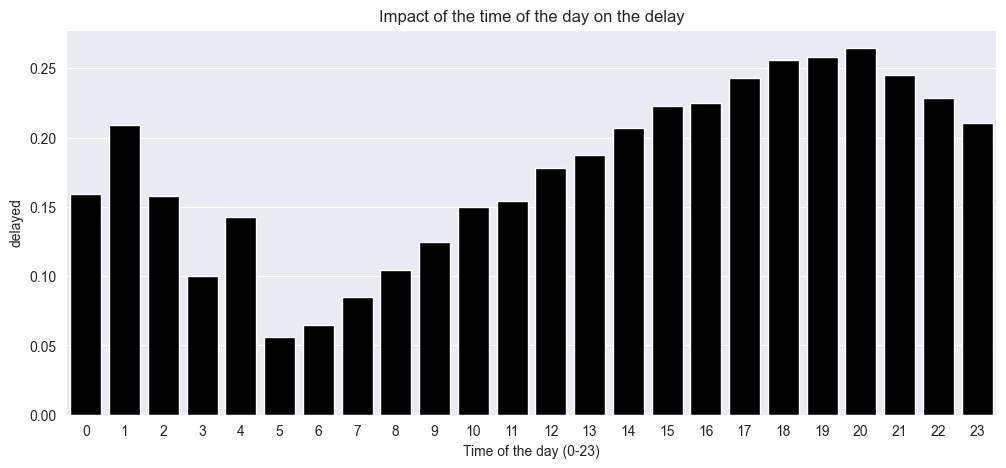

In [18]:
# Extraction de l'heure depuis SCHEDULED_DEPARTURE (format HHMM, ex: 1730)
df_clean['HOUR'] = (df_clean['SCHEDULED_DEPARTURE'] // 100).astype(int)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_clean, x='HOUR', y='delayed', color='black', errorbar=None)
plt.title('Impact of the time of the day on the delay')
plt.xlabel('Time of the day (0-23)')
plt.show()

In [20]:
# On renomme AIRLINE_y pour faire propre
df_clean = df_clean.rename(columns={'AIRLINE_y': 'airline_name'})

# On sauvegarde pour le notebook 2
df_clean.to_csv("flight_delays_cleaned_sample.csv", index=False)
print("We can now see some patterns emerging from the dataset with our random sample of 100,000 flights.")
print("Clean data saved in 'flight_delays_cleaned_sample.csv'")

We can now see some patterns emerging from the dataset with our random sample of 100,000 flights.
Clean data saved in 'flight_delays_cleaned_sample.csv'
